In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cd drive/MyDrive/

/content/drive/MyDrive


In [ ]:
test = pd.read_csv('test_battery_V6.csv')

#
### **🚧 4. 혼잡 / 경로 / 충돌 (Traffic)**
* congestion_score → 창고 혼잡도 점수
* max_zone_density → 특정 구역 최대 밀집도
* blocked_path_15m → 막힌 경로 수 (15분)
* near_collision_15m → 충돌 직전 이벤트 수
* aisle_traffic_score → 통로 교통량 점수
* intersection_wait_time_avg → 교차로 평균 대기 시간
* path_optimization_score → 경로 최적화 점수

  
layout_info.csv
* aisle_width_avg → 평균 통로 너비
* intersection_count → 교차로 개수
* one_way_ratio → 일방통행 비율

In [ ]:
test_traffic = test[["congestion_score","max_zone_density","blocked_path_15m",
        "near_collision_15m","aisle_traffic_score",
        "intersection_wait_time_avg","path_optimization_score",
        "aisle_width_avg","intersection_count","one_way_ratio"]]
test_traffic

,congestion_score,max_zone_density,blocked_path_15m,near_collision_15m,aisle_traffic_score,intersection_wait_time_avg,path_optimization_score,aisle_width_avg,intersection_count,one_way_ratio
0,16.70,0.0682,0.0,0.0,47.7,1.63,75.5,2.53,46.0,0.2380
1,20.04,0.0909,2.0,0.0,45.5,2.39,76.1,2.53,46.0,0.2380
2,25.05,0.1136,0.0,2.0,50.3,NaN,91.8,2.53,46.0,0.2380
3,16.70,0.1136,1.0,3.0,54.2,1.03,78.7,2.53,46.0,0.2380
4,15.03,0.0909,1.0,2.0,47.6,0.87,80.4,2.53,46.0,0.2380
...,...,...,...,...,...,...,...,...,...,...
49995,0.00,0.0000,0.0,0.0,6.0,0.00,86.6,2.64,54.0,0.1054
49996,0.00,0.0000,0.0,0.0,18.0,0.00,93.7,2.64,54.0,0.1054
49997,NaN,0.0556,NaN,0.0,NaN,0.32,89.5,2.64,54.0,0.1054
49998,0.00,0.0000,0.0,NaN,14.7,1.59,91.5,2.64,54.0,0.1054


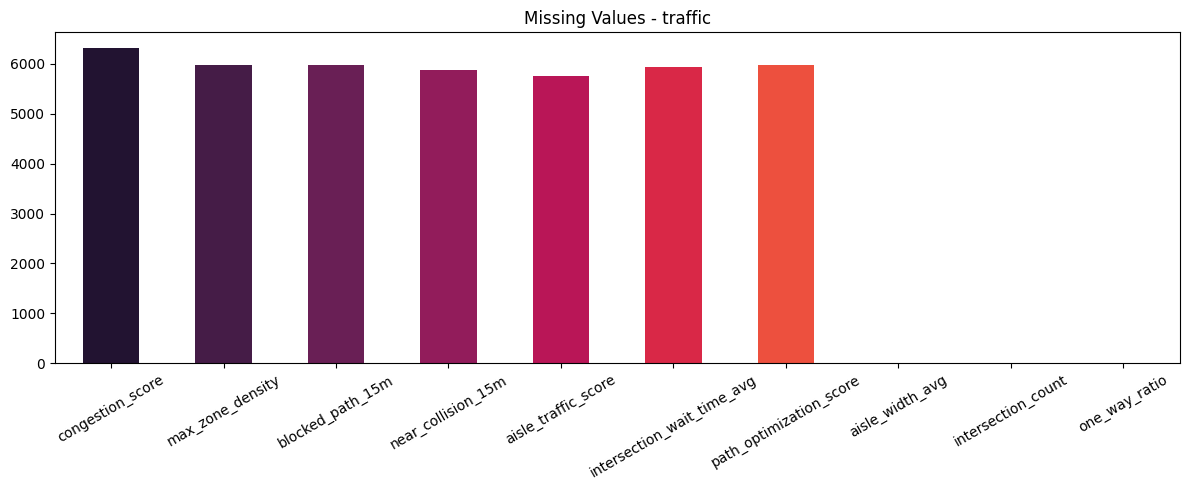

In [ ]:
missing = test_traffic.isnull().sum()

colors = sns.color_palette("rocket", len(missing))

plt.figure(figsize=(12, 5))
missing.plot(kind='bar', color=colors)

plt.title('Missing Values - traffic')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#####
① **congestion_score** 결측치 채우기

In [ ]:
from sklearn.ensemble import RandomForestRegressor

cols = [
    "congestion_score",
    "max_zone_density",
    "blocked_path_15m",
    "near_collision_15m"
]

target = "congestion_score"
features = ["max_zone_density", "blocked_path_15m", "near_collision_15m"]

# 결측 없는 행으로 학습
train_rf = test_traffic.dropna(subset=cols)

X = train_rf[features]
y = train_rf[target]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# 결측 채우기
mask = test_traffic[target].isna()

test_traffic.loc[mask, target] = model.predict(
    test_traffic.loc[mask, features]
)

In [ ]:
test["congestion_score"] = test_traffic["congestion_score"]

In [ ]:
test[["congestion_score", "blocked_path_15m", "max_zone_density", "near_collision_15m"]].isnull().sum().to_frame(name="NaN")

,NaN
congestion_score,0
blocked_path_15m,5981
max_zone_density,5985
near_collision_15m,5876


In [ ]:
# test.to_csv("test_traffic_V2.csv", index=False)

#####
② **blocked_path_15m** 결측치 채우기

In [ ]:
target = "blocked_path_15m"
features = ["congestion_score", "max_zone_density", "near_collision_15m"]

train_rf = test_traffic.dropna(subset=[target] + features)

X = train_rf[features]
y = train_rf[target]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

mask = test_traffic[target].isna()
test_traffic.loc[mask, target] = model.predict(
    test_traffic.loc[mask, features]
)

In [ ]:
test["blocked_path_15m"] = test_traffic["blocked_path_15m"]

In [ ]:
test[["congestion_score", "blocked_path_15m", "max_zone_density", "near_collision_15m"]].isnull().sum().to_frame(name="NaN")

,NaN
congestion_score,0
blocked_path_15m,0
max_zone_density,5985
near_collision_15m,5876


In [ ]:
# test.to_csv("test_traffic_V3.csv", index=False)

#####
③ **near_collision_15m** 결측치 채우기

In [ ]:
target = "near_collision_15m"
features = ["congestion_score", "blocked_path_15m", "max_zone_density"]

train_rf = test_traffic.dropna(subset=[target] + features)

X = train_rf[features]
y = train_rf[target]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

mask = test_traffic[target].isna()
test_traffic.loc[mask, target] = model.predict(
    test_traffic.loc[mask, features]
)

In [ ]:
test["near_collision_15m"] = test_traffic["near_collision_15m"]

In [ ]:
test[["congestion_score", "blocked_path_15m", "max_zone_density", "near_collision_15m"]].isnull().sum().to_frame(name="NaN")

,NaN
congestion_score,0
blocked_path_15m,0
max_zone_density,5985
near_collision_15m,0


In [ ]:
test.to_csv("test_traffic_V4.csv", index=False)

#####
④ **max_zone_density** 결측치 채우기

In [ ]:
target = "max_zone_density"
features = ["congestion_score", "blocked_path_15m", "near_collision_15m"]

train_rf = test_traffic.dropna(subset=[target] + features)

X = train_rf[features]
y = train_rf[target]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

mask = test_traffic[target].isna()
test_traffic.loc[mask, target] = model.predict(
    test_traffic.loc[mask, features]
)

In [ ]:
test["max_zone_density"] = test_traffic["max_zone_density"]

In [ ]:
test[["congestion_score", "blocked_path_15m", "max_zone_density", "near_collision_15m"]].isnull().sum().to_frame(name="NaN")

,NaN
congestion_score,0
blocked_path_15m,0
max_zone_density,0
near_collision_15m,0


In [ ]:
# test.to_csv("test_traffic_V5.csv", index=False)

#####
* layout_info 컬럼들 추가된 버전

In [ ]:
test.to_csv("test_traffic_V6.csv", index=False)